In [1]:
from db.database import Database
import pandas as pd
from util.filtering.lang_identification import identify_language_yaml
from util.filtering.structural_diff import filter_similar_blueprints



In [4]:
# %%
db = Database()
from util.filtering.structural_diff import compare_multiple_bps
from tqdm import tqdm
bps = {bp.id: bp for bp in db.get_all_blueprints()}
bp_df = pd.DataFrame(
    [
        {_attr: getattr(bp, _attr) for _attr in bp.__dict__.keys()}
        for bp in bps.values()
    ]
)
bp_df["language"] = bp_df["blueprint_code"].apply(identify_language_yaml)
bp_df_en = bp_df[bp_df["language"] == "en"]

similarities = []

unique_topics = bp_df_en["topic_id"].unique()
for topic_id in tqdm(unique_topics, desc="Filtering blueprints by topic"):
    topic_bp_df = bp_df_en[bp_df_en["topic_id"] == topic_id]
    codes = topic_bp_df["blueprint_code"].tolist()
    comparisons = compare_multiple_bps(codes)
    similar_codes = set()
    for _, _, similarity in comparisons:
        similarities.append(similarity)





Filtering blueprints by topic: 100%|██████████| 1184/1184 [13:19<00:00,  1.48it/s] 


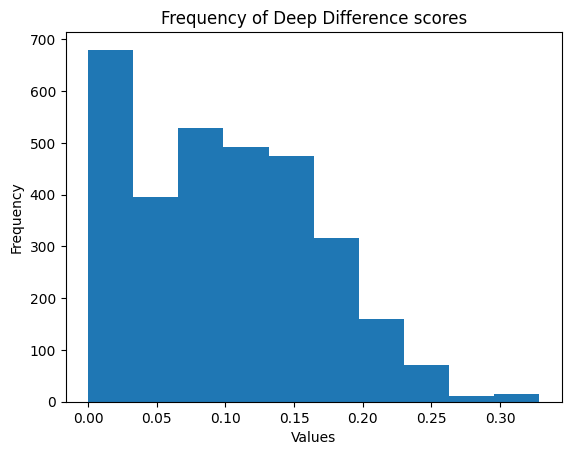

In [5]:
import matplotlib.pyplot as plt

plt.hist(similarities)
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Frequency of Deep Difference scores")
plt.show()


